In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from network_funcs import S2_graph_definite_N, plot_graph_on_sphere
import numpy as np

# Barabási-Albert (BA) Model
The BA model generates scale-free networks using a preferential attachment mechanism.

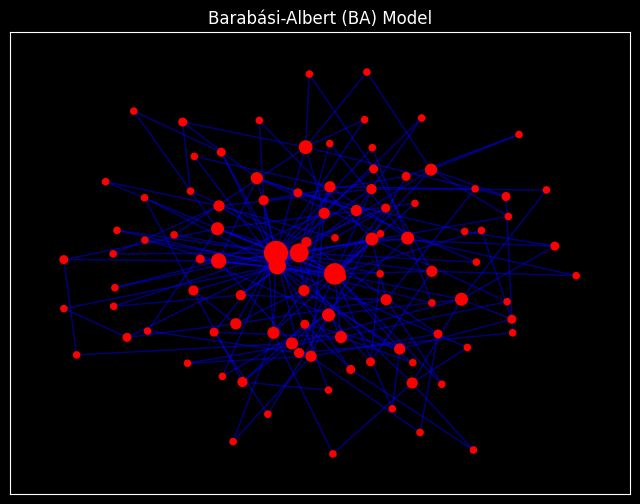

In [45]:
G = nx.barabasi_albert_graph(100, 2)  # 100 nodes, each new node attaches to 3 existing nodes
degrees =dict(G.degree())
node_size = [v * 10 for v in degrees.values()]  # Scale node size by degree
pos = nx.spring_layout(G, k=0.5)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G,pos,node_size=node_size,node_color='red')
nx.draw_networkx_edges(G,pos,alpha=0.5, edge_color='blue')
plt.title("Barabási-Albert (BA) Model")
plt.savefig("BA_model.pdf")
plt.show()

# Extended Barabási-Albert (EBA) Model
The EBA model extends the BA model by allowing for additional parameters that control the attachment process, such as the probability of adding edges between existing nodes.

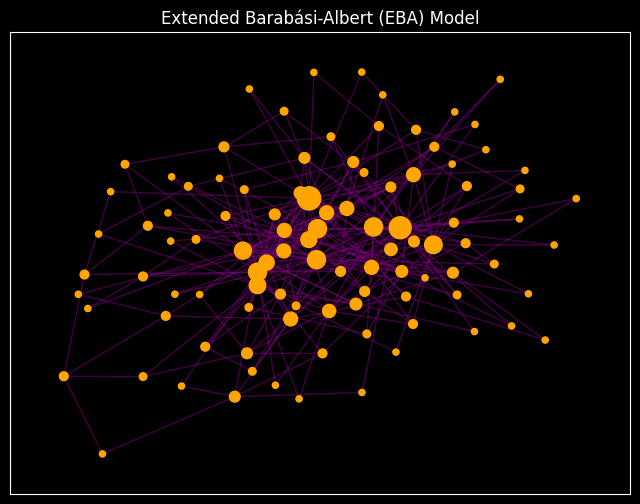

In [44]:
G_EBA = nx.extended_barabasi_albert_graph(100, 2, 0.3, 0.1)  # 100 nodes, m=2, p=0.5
degrees_EBA = dict(G_EBA.degree())
node_size_EBA = [v * 10 for v in degrees_EBA.values()] # Scale node size by degree
pos_EBA = nx.spring_layout(G_EBA, k=0.25)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_EBA, pos_EBA, node_size=node_size_EBA, node_color='orange')
nx.draw_networkx_edges(G_EBA, pos_EBA, alpha=0.5, edge_color='purple')
plt.title("Extended Barabási-Albert (EBA) Model")
plt.savefig("EBA_model.pdf")
plt.show()

In [65]:
# Define the parameter sets for the Extended BA model
# m=1 (base connection), p (add edge prob), q (rewire edge prob)
params = [
    {"m": 1, "p": 0.05, "q": 0.05, "filename": "Extended_model_baseline.pdf", "title": "Baseline (p=0.05, q=0.05)"},
    {"m": 1, "p": 0.30, "q": 0.05, "filename": "Extended_model_mesh.pdf",     "title": "Resilient Mesh (p=0.30)"},
    {"m": 1, "p": 0.05, "q": 0.30, "filename": "Extended_model_hyper.pdf",    "title": "Hyper-Centralised (q=0.30)"}
]

for param in params:
    # 1. Generate Graph
    G = nx.extended_barabasi_albert_graph(n=100, m=param["m"], p=param["p"], q=param["q"], seed=42)

    # 2. Color by degree threshold to separate Core from Edge
    colors = []
    sizes = []
    for node in G.nodes():
        if G.degree(node) > 3:
            colors.append('#D55E00')  # Dark Orange (Core/Hubs)
            sizes.append(150)
        else:
            colors.append('#F0E442')  # Light Yellow (Users)
            sizes.append(30)

    # 3. Plot and Save
    plt.figure(figsize=(8, 6))

    # Kamada-Kawai keeps the spatial Core-Edge separation consistent with your Dual BA plots
    pos = nx.kamada_kawai_layout(G)

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(param["filename"], format="pdf", bbox_inches="tight")
    plt.close()

# Dual Barabási-Albert (EBA) Model
The Dual Barabási-Albert model is a variation of the BA model that incorporates two different attachment mechanisms, allowing for more complex network structures. It can be used to model networks where nodes have different types of connections or where the attachment process is influenced by multiple factors.

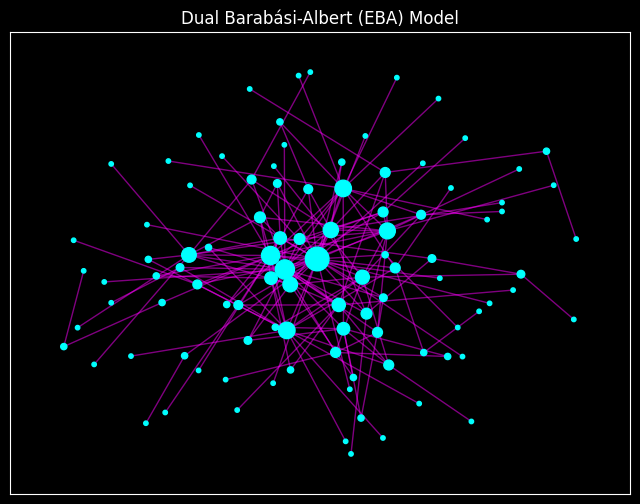

In [42]:
G_BA2 = nx.dual_barabasi_albert_graph(100, 8, 1, 0.1)  # 100 nodes, m1=2, m2=3, p=0.5
degrees_BA2 = dict(G_BA2.degree())
node_size_BA2 = [v * 10 for v in degrees_BA2.values()]  # Scale node size by degree
pos_BA2 = nx.spring_layout(G_BA2, k=0.5)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_BA2, pos_BA2, node_size=node_size_BA2, node_color='cyan')
nx.draw_networkx_edges(G_BA2, pos_BA2, alpha=0.5, edge_color='magenta')
plt.title("Dual Barabási-Albert (EBA) Model")
plt.savefig("Dual_model.pdf")
plt.show()

In [63]:

# Define the parameter sets we want to test
params = [
    {"m1": 5,  "m2": 1, "p": 0.05, "filename": "Dual_model_baseline.pdf", "title": "Baseline (m1=5, p=0.05)"},
    {"m1": 15, "m2": 1, "p": 0.05, "filename": "Dual_model_heavy.pdf",    "title": "Heavy Backbone (m1=15, p=0.05)"},
    {"m1": 5,  "m2": 1, "p": 0.15, "filename": "Dual_model_dist.pdf",     "title": "Distributed Core (m1=5, p=0.15)"}
]

for param in params:
    # 1. Generate Graph
    G = nx.dual_barabasi_albert_graph(n=100, m1=param["m1"], m2=param["m2"], p=param["p"], seed=42)

    # 2. Color by degree threshold (Hub vs User)
    colors = []
    sizes = []
    for node in G.nodes():
        if G.degree(node) > 3:
            colors.append('#0072B2')  # Dark Blue (Hubs)
            sizes.append(150)
        else:
            colors.append('#56B4E9')  # Light Blue (Users)
            sizes.append(30)

    # 3. Plot and Save
    plt.figure(figsize=(8, 6))
    pos = nx.kamada_kawai_layout(G)

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, edgecolors='white')
    nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(param["filename"], format="pdf", bbox_inches="tight")
    plt.close() # Close figure to free memory

# Watts-Strogatz (WS) Model
The WS model generates small-world networks by rewiring edges with a certain probability.

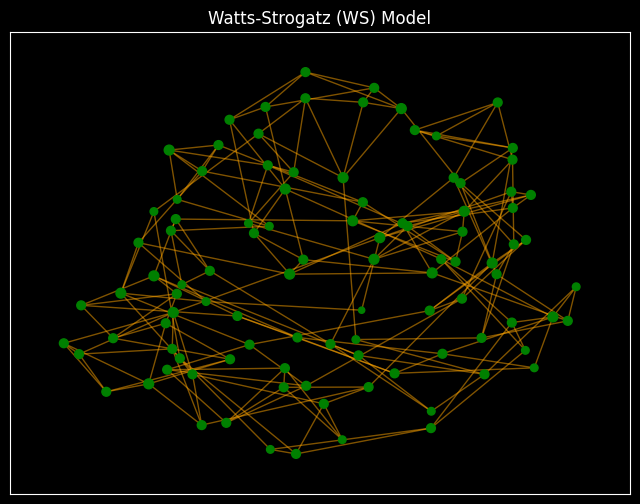

In [28]:
G_ws = nx.watts_strogatz_graph(100, 4, 0.1)  # 100 nodes, each node connected to 4 neighbors, rewiring probability 0.1
degrees_ws = dict(G_ws.degree())
node_size_ws = [v * 10 for v in degrees_ws.values()]  # Scale
pos_ws = nx.spring_layout(G_ws, k=0.5)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_ws, pos_ws, node_size=node_size_ws, node_color='green')
nx.draw_networkx_edges(G_ws, pos_ws, alpha=0.5, edge_color='orange')
plt.title("Watts-Strogatz (WS) Model")
plt.savefig("WS_model.pdf")
plt.show()

# Luca's S2 Graph Model
Luca's S2 graph model generates networks based on points distributed on a sphere, with edges formed based on a distance threshold.

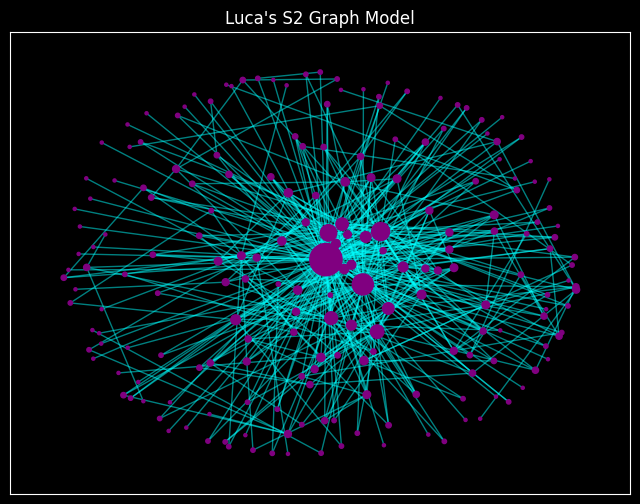

In [64]:
A, _, coords = S2_graph_definite_N(200, 2.6, 0.0233, return_coords=True)
G_s2 = nx.from_numpy_array(A)  # Convert adjacency matrix to graph
degrees_s2 = dict(G_s2.degree())
node_size_s2 = [v * 5 for v in degrees_s2.values()]
pos_s2 = nx.spring_layout(G_s2, k=0.7)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_s2, pos_s2, node_size=node_size_s2, node_color='purple')
nx.draw_networkx_edges(G_s2, pos_s2, alpha=0.5, edge_color='cyan')
plt.title("Luca's S2 Graph Model")
plt.savefig("S2_model_sping.pdf")
plt.show()

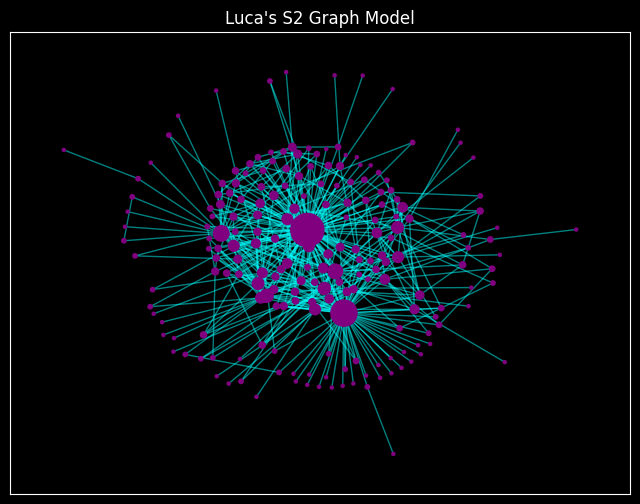

In [53]:
pos_s2 = nx.kamada_kawai_layout(G_s2)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_s2, pos_s2, node_size=node_size_s2, node_color='purple')
nx.draw_networkx_edges(G_s2, pos_s2, alpha=0.5, edge_color='cyan')
plt.title("Luca's S2 Graph Model")
plt.savefig("S2_model_kamada.pdf")
plt.show()

In [61]:
plot_graph_on_sphere(coords, A, R=1, filename="S2_model_sphere.pdf")

# Start Graph
The Start graph is a simple graph structure that serves as a baseline for comparison with more complex network models. It typically consists of a small number of nodes and edges, often arranged in a regular pattern, such as a ring or a grid.

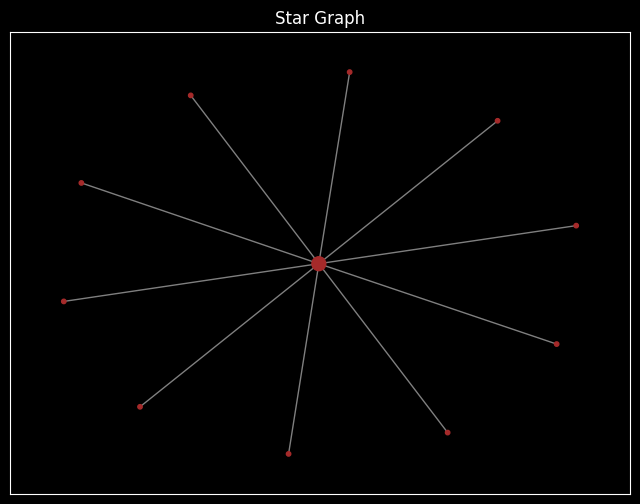

In [47]:
G_star = nx.star_graph(10)  # Create a star graph with 10 peripheral nodes
degrees_star = dict(G_star.degree())
node_size_star = [v * 10 for v in degrees_star.values()]  # Scale node size by degree
pos_star = nx.spring_layout(G_star, k=0.5)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_star, pos_star, node_size=node_size_star, node_color='brown')
nx.draw_networkx_edges(G_star, pos_star, alpha=0.5, edge_color='white')
plt.title("Star Graph")
plt.savefig("Star_graph.pdf")
plt.show()

# Stochastic Block Model (SBM)
The SBM is a generative model for random graphs that can produce community structures by defining blocks of nodes with different probabilities of connection.

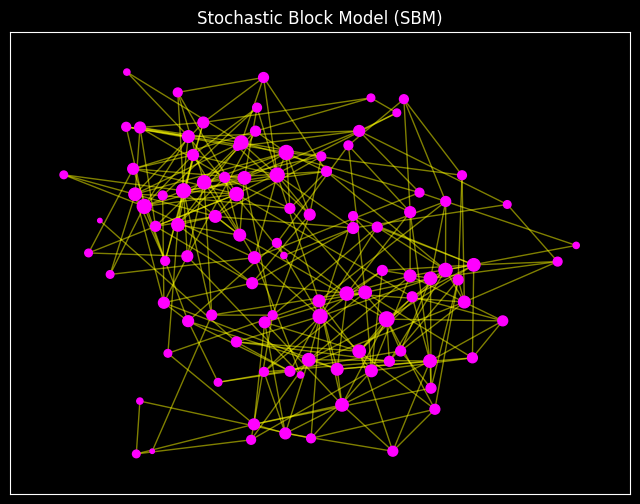

In [48]:
G_SBM = nx.stochastic_block_model([50, 50], [[0.1, 0.01], [0.01, 0.1]])  # 2 blocks of 50 nodes each, with different connection probabilities
degrees_SBM = dict(G_SBM.degree())
node_size_SBM = [v * 10 for v in degrees_SBM.values()] # Scale node size by degree
pos_SBM = nx.spring_layout(G_SBM, k=0.5)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_SBM, pos_SBM, node_size=node_size_SBM, node_color='magenta')
nx.draw_networkx_edges(G_SBM, pos_SBM, alpha=0.5, edge_color='yellow')
plt.title("Stochastic Block Model (SBM)")
plt.savefig("SBM_model.pdf")
plt.show()

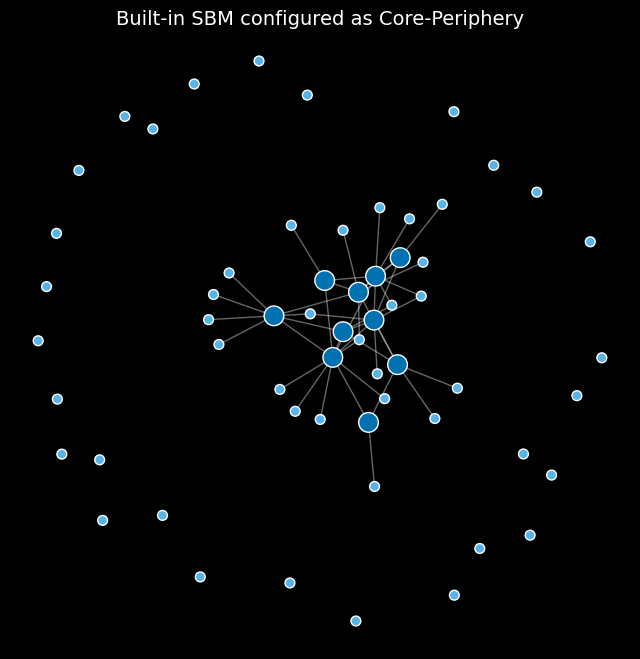

In [51]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define the sizes of the 3 blocks
# 10 backbone routers, 25 users on one side, 25 users on the other
sizes = [10, 25, 25]

# 2. Define the Probability Matrix (This is the secret sauce!)
# p_core_core = 0.4  (Dense inner mesh)
# p_user_user = 0.0  (Users NEVER connect to other users)
# p_core_user = 0.05 (Users connect sparsely to the core, acting like starbursts)

probs = [
    [0.40, 0.05, 0.05],  # Block 0 (Core) connections
    [0.05, 0.00, 0.00],  # Block 1 (Users A) connections
    [0.05, 0.00, 0.00]   # Block 2 (Users B) connections
]

# 3. Generate the built-in SBM
G_sbm = nx.stochastic_block_model(sizes, probs, seed=42)

# 4. Plot it to see the Core-Periphery shape
plt.figure(figsize=(8, 8))
plt.title("Built-in SBM configured as Core-Periphery", fontsize=14)

# Spring layout works well here because the "zero probability" users
# will naturally be pushed to the outside edges!
pos = nx.spring_layout(G_sbm, k=0.3)

# Color the Core nodes dark blue, and the User nodes light blue
colors = ['#0072B2']*10 + ['#56B4E9']*25 + ['#56B4E9']*25
sizes_list = [200]*10 + [50]*25 + [50]*25

nx.draw_networkx_nodes(G_sbm, pos, node_color=colors, node_size=sizes_list, edgecolors='white')
nx.draw_networkx_edges(G_sbm, pos, alpha=0.4, edge_color='white')

plt.axis('off')
plt.show()

# Bianconi-Barabási (BB) Model
The BB model is an extension of the BA model that incorporates node fitness, allowing for a more realistic representation of networks where nodes have varying levels of attractiveness for new connections.

In [68]:

def generate_bb_model(n_nodes, m_edges, fitness_dict, seed=42):
    """Custom generator for the Bianconi-Barabási Fitness Model."""
    np.random.seed(seed)
    G = nx.complete_graph(m_edges + 1)

    for new_node in range(m_edges + 1, n_nodes):
        degrees = dict(G.degree())
        # The core BB equation: Probability ~ Degree * Fitness
        weights = [degrees[node] * fitness_dict.get(node, 0.1) for node in G.nodes()]
        total_weight = sum(weights)
        probabilities = [w / total_weight for w in weights]

        # Connect to existing nodes based on this probability
        targets = np.random.choice(G.nodes(), size=m_edges, replace=False, p=probabilities)

        G.add_node(new_node)
        for target in targets:
            G.add_edge(new_node, target)

    return G

n = 100
m = 1

# 1. Uniform Fitness (Standard BA)
fit_uniform = {i: 1.0 for i in range(n)}

# 2. Bimodal Fitness (5 Quantum Hubs, 95 End Users)
fit_bimodal = {i: 10.0 if i < 5 else 0.1 for i in range(n)}

# 3. Bose-Einstein Condensation (1 Absolute Monopoly Super-Hub)
fit_condense = {i: 1000.0 if i == 50 else 0.1 for i in range(n)}

scenarios = [
    {"fit": fit_uniform,  "name": "BB_model_uniform.pdf",  "title": "Uniform (Standard BA)"},
    {"fit": fit_bimodal,  "name": "BB_model_bimodal.pdf",  "title": "Bimodal (Core-Edge)"},
    {"fit": fit_condense, "name": "BB_model_condense.pdf", "title": "Bose-Einstein Condensation"}
]

for s in scenarios:
    G = generate_bb_model(n_nodes=n, m_edges=m, fitness_dict=s["fit"])

    # Color based on fitness to show cause-and-effect!
    colors = []
    sizes = []
    for node in G.nodes():
        if s["fit"].get(node, 0.1) >= 10.0: # High fitness
            colors.append('#D55E00')
            sizes.append(150)
        else:
            colors.append('#009E73')
            sizes.append(30)

    plt.figure(figsize=(8, 6))
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, edgecolors='white')
    nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(s["name"], format="pdf", bbox_inches="tight")
    plt.close()

## Dijkstra algorithm

In [6]:
def brute_force_dijkstra(graph, start_node, target_node):
    """
    Finds the shortest path using pure brute-force Dijkstra (no external libraries).
    """
    # Step 1: Initialise distances and previous nodes
    distances = {node: float('inf') for node in graph}
    distances[start_node] = 0
    previous_nodes = {node: None for node in graph}

    # Keep a simple list of all nodes we haven't checked yet
    unvisited = list(graph.keys())

    # Step 2: The Main Loop
    while unvisited:
        # --- THE BRUTE FORCE PART ---
        # Manually search the unvisited list for the node with the lowest distance
        current_node = None
        current_min_distance = float('inf')

        for node in unvisited:
            if distances[node] < current_min_distance:
                current_min_distance = distances[node]
                current_node = node

        # If the lowest distance is infinity, it means the remaining nodes are completely
        # disconnected from our start node. We can stop searching.
        if current_node is None:
            break

        # If we found our target, we can stop early!
        if current_node == target_node:
            break

        # Step 3: Explore neighbours
        for neighbour, weight in graph[current_node].items():
            # Only check neighbours that haven't been visited yet
            if neighbour in unvisited:
                # Calculate the cost to reach this neighbour
                distance_to_neighbour = distances[current_node] + weight

                # Step 4: Update if we found a better route
                if distance_to_neighbour < distances[neighbour]:
                    distances[neighbour] = distance_to_neighbour
                    previous_nodes[neighbour] = current_node

        # Step 5: Mark the current node as visited by removing it from the list
        unvisited.remove(current_node)

    # --- Step 6: Path Reconstruction ---
    path = []
    current = target_node

    while current is not None:
        path.append(current)
        current = previous_nodes[current]

    path.reverse()

    if len(path) == 1 and start_node != target_node:
        return float('inf'), []

    return distances[target_node], path

# ==========================================
# Example Usage on a Small Network
# ==========================================
quantum_network = {
    'Alice': {'Repeater1': 2, 'Repeater2': 5},
    'Repeater1': {'Alice': 2, 'Repeater2': 1, 'Bob': 6},
    'Repeater2': {'Alice': 5, 'Repeater1': 1, 'Bob': 2},
    'Bob': {'Repeater1': 1, 'Repeater2': 10}
}

cost, routing_path = brute_force_dijkstra(quantum_network, 'Alice', 'Bob')

print(f"Total Path Cost: {cost}")
print(f"Optimal Routing Path: {routing_path}")

Total Path Cost: 5
Optimal Routing Path: ['Alice', 'Repeater1', 'Repeater2', 'Bob']


## Erdos-Renyi

